In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/raw/telco.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Les statistiques descriptives révèlent plusieurs éléments clés :
- `tenure` : moyenne de 32 mois (std=24), indiquant une base client hétérogène
  avec des profils très récents et très anciens
- `MonthlyCharges` : moyenne de 64€ (std=30), avec une forte dispersion
  suggérant des offres très variées
- `TotalCharges` : très corrélé à tenure × MonthlyCharges, à surveiller
  pour éviter la multicolinéarité

In [4]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'].dtype

<StringDtype(storage='python', na_value=nan)>

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].dtype

dtype('float64')

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df['TotalCharges'].unique()[:20]

array([  29.85, 1889.5 ,  108.15, 1840.75,  151.65,  820.5 , 1949.4 ,
        301.9 , 3046.05, 3487.95,  587.45,  326.8 , 5681.1 , 5036.3 ,
       2686.05, 7895.15, 1022.95, 7382.25,  528.35, 1862.9 ])

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [12]:
df[df['TotalCharges'].isnull()]['tenure'].value_counts()

tenure
0    11
Name: count, dtype: int64

Les 11 valeurs manquantes dans `TotalCharges` correspondent toutes à des clients
avec un tenure de 0 mois, c'est-à-dire des clients n'ayant généré aucune facturation.
Ces lignes sont supprimées car elles n'apportent pas d'information exploitable pour
la modélisation du churn.

In [13]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Environ 26% des clients quittent le service.

Ce taux de churn est significatif et justifie la mise en place d’un modèle prédictif afin d’anticiper les départs.

In [14]:
df = df.dropna()

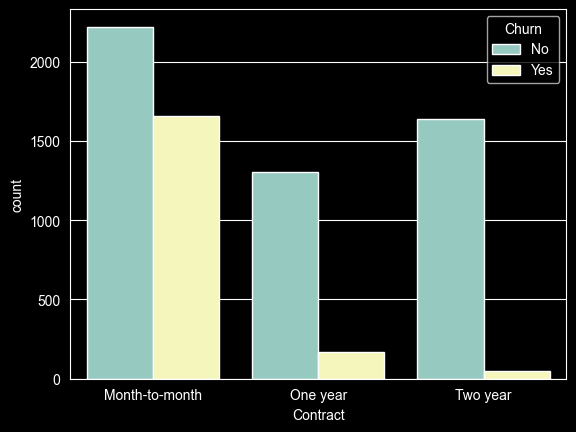

In [15]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

Les clients avec un contrat mensuel présentent un taux de churn significativement plus élevé que ceux engagés sur un ou deux ans.

Cela suggère que l’engagement contractuel joue un rôle clé dans la rétention client.

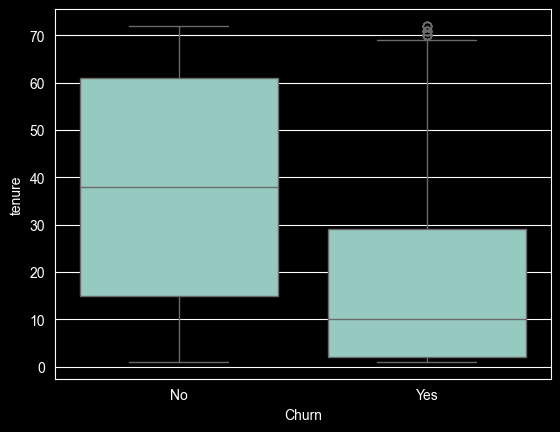

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

Les clients ayant une ancienneté faible (tenure bas) sont plus susceptibles de churner.

Cela indique que les premières phases du cycle de vie client sont critiques pour la rétention.

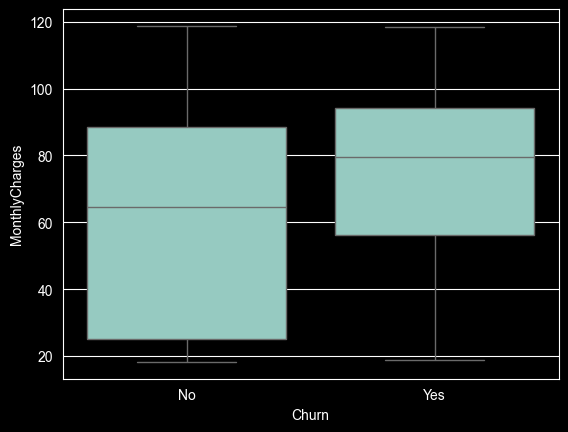

In [17]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

Les clients ayant des charges mensuelles élevées présentent un taux de churn plus important.

Cela suggère une sensibilité au prix ou une inadéquation entre le coût et la valeur perçue.

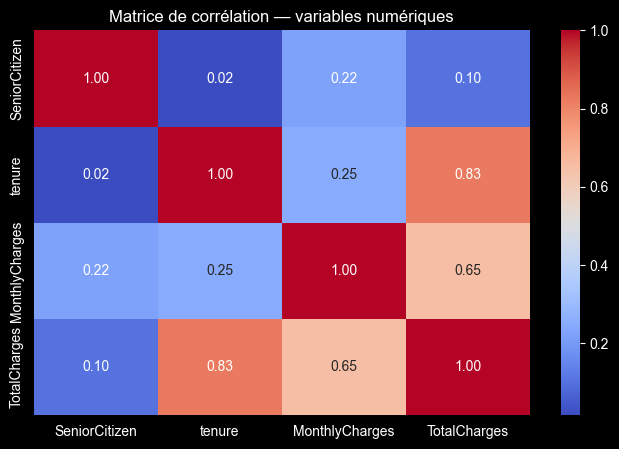

In [18]:
num_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation — variables numériques")
plt.show()

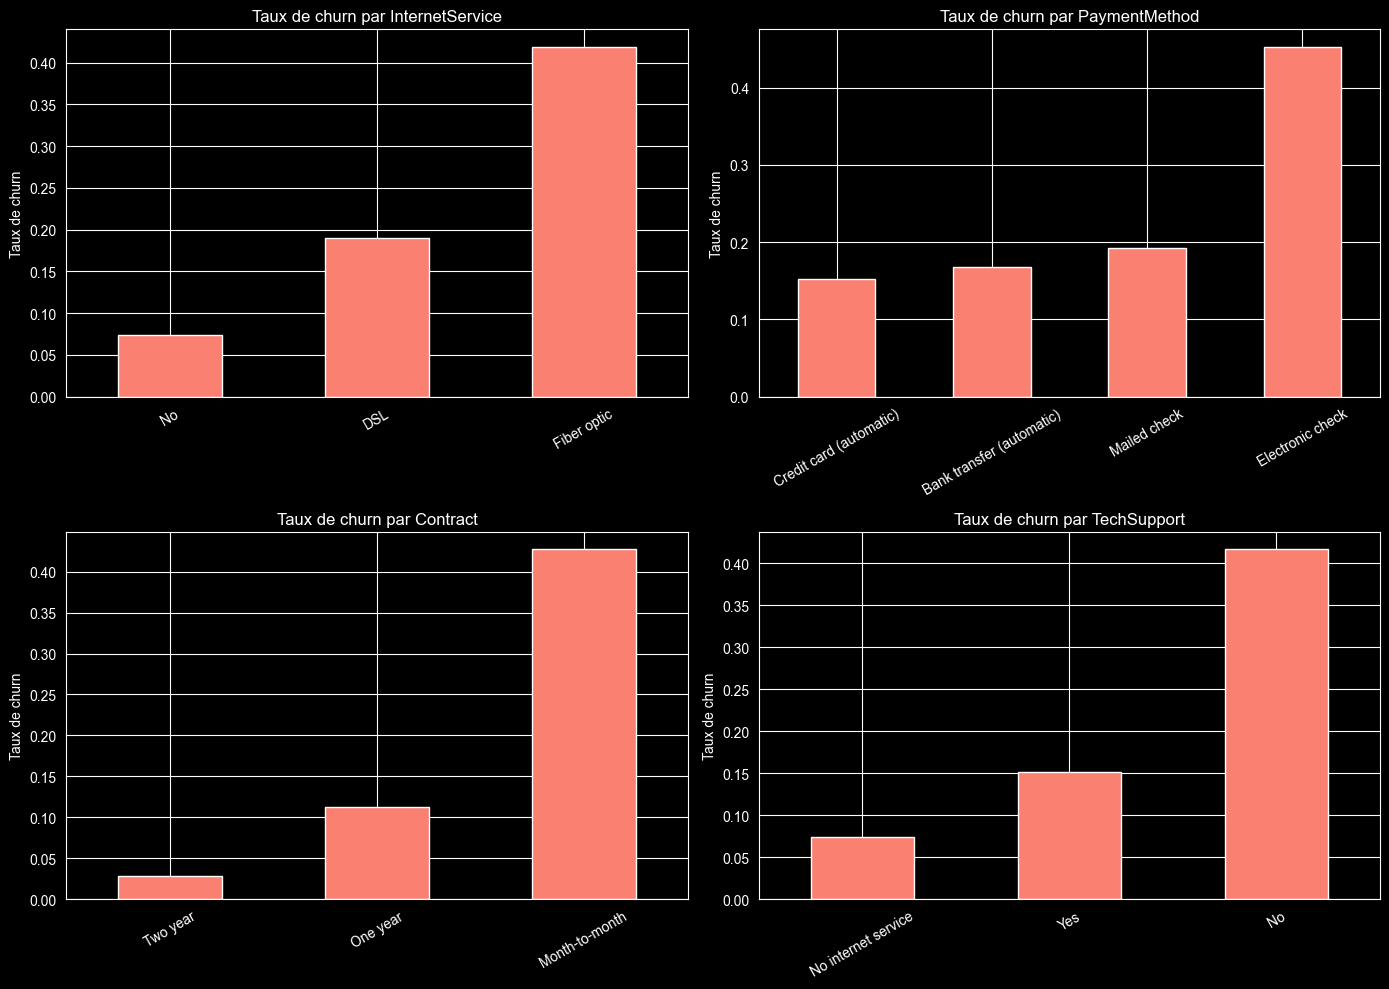

In [19]:
cat_cols = ['InternetService', 'PaymentMethod', 'Contract', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    churn_rate['Yes'].sort_values().plot(kind='bar', ax=ax, color='salmon')
    ax.set_title(f"Taux de churn par {col}")
    ax.set_ylabel("Taux de churn")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

L'analyse des variables catégorielles confirme plusieurs facteurs de churn :
- **InternetService** : les clients avec fibre optique churne davantage
  que ceux avec DSL ou sans internet
- **PaymentMethod** : le paiement par chèque électronique est associé
  à un taux de churn plus élevé
- **Contract** : confirme l'analyse précédente, le contrat mensuel
  est le facteur le plus discriminant
- **TechSupport** : les clients sans support technique churne plus,
  suggérant un lien entre satisfaction et rétention

## Déséquilibre de classes

Le dataset présente un déséquilibre modéré : 73% non-churn vs 27% churn.
Ce déséquilibre peut biaiser le modèle vers la classe majoritaire.

Trois stratégies seront évaluées lors de la phase de modélisation :
- **class_weight='balanced'** : ajuste automatiquement les poids dans
  Scikit-learn, sans modifier les données
- **SMOTE** : génère des exemples synthétiques de la classe minoritaire
  pour rééquilibrer le dataset d'entraînement
- **Ajustement du seuil de décision** : abaisser le seuil de 0.5
  pour augmenter le recall sur la classe churn

Le choix final sera guidé par la métrique **F1-score** plutôt que
l'accuracy, plus adaptée aux datasets déséquilibrés.

## Synthèse des insights

L’analyse met en évidence plusieurs facteurs clés influençant le churn :

- Les contrats mensuels sont fortement associés à un taux de churn élevé
- Les nouveaux clients sont plus susceptibles de quitter le service
- Des charges mensuelles élevées augmentent le risque de churn

Ces éléments permettent d’orienter la construction du modèle prédictif et les stratégies de rétention client.